In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import re
from collections import Counter, defaultdict
from scipy.stats import hypergeom, spearmanr, mannwhitneyu, mstats, chi2_contingency

## Comparing iHS values

Here, we do some pre-processing of the iHS data and select the score for the population we need

In [2]:
ihs_dir = '/mnt/data/phenome_proj/evolution/iHS/'
ihs_data = [x for x in os.listdir(ihs_dir) if x.endswith('.txt')]

In [3]:
testfile = '/mnt/data/phenome_proj/evolution/iHS/chr3.1kg.p3.allPops.iHS.txt'
with open(testfile, 'r') as tt:
    for line in tt:
        if line.startswith('##populations'):
            pop_list = line.strip().split()[2].split('|')
            for idx, pop in enumerate(pop_list):
                print(f'{idx}: {pop}')
            break

0: ESN
1: GWD
2: LWK
3: MSL
4: YRI
5: ACB
6: ASW
7: CLM
8: MXL
9: PEL
10: PUR
11: CDX
12: CHB
13: CHS
14: JPT
15: KHV
16: CEU
17: FIN
18: GBR
19: IBS
20: TSI
21: BEB
22: GIH
23: ITU
24: PJL
25: STU


In [4]:
ihs_dict = {}
for ihsfile in ihs_data:
    with open(f'{ihs_dir}{ihsfile}', 'r') as ihs_handle:
        for line in ihs_handle:
            if line.startswith('#') or 'CHR' in line:
                continue
            content = line.strip().split('\t')
            ihs_value = content[4].split('|')[18]
            if ihs_value == 'NA':
                ihs_value = None
            else:
                ihs_value = np.float64(ihs_value)
            ihs_dict[content[2]] = ihs_value

In [5]:
for ihsfile in ihs_data:
    outfile = ihsfile.replace('txt', 'bed')
    with open(f'{ihs_dir}{ihsfile}', 'r') as ihs_handle, open(f'{ihs_dir}{outfile}', 'w') as out_handle:
        for line in ihs_handle:
            if line.startswith('#') or 'CHR' in line:
                continue
            content = line.strip().split('\t')
            ihs_value = content[4].split('|')[18]
            pos = int(content[1])
            out_handle.write(f'{content[0]}\t{pos - 1}\t{pos + 1}\t{ihs_value}\n')

In [6]:
!cat /mnt/data/phenome_proj/evolution/iHS/*.iHS.bed | \
    sort -k1,1 -k2,2n > /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed

### Case 1. Looking at the exact lead SNP

In [18]:
data_dir = '/mnt/data/phenome_proj/finngen/clumping'
file_list = os.listdir(data_dir)
formatted = [x for x in file_list if x.endswith('.genes.bed')]

In [19]:
len(formatted)

906

In the following section, I have to correct for the $r_g$ values between pairs of traits to ensure no false labelling of variants as plaiotropic. To do so, I will use the matrix that is exported in the first part of the pleiotropy analysis pipeline.

In [210]:
trait_clustering = pd.read_csv('/mnt/data/phenome_proj/evolution/panukb_clusters.txt', sep='\t')
trait_clustering.index = trait_clustering['pheno_name']
trait_clustering.head()

,pheno_name,cluster
pheno_name,,
continuous-5117,continuous-5117,33
continuous-20514,continuous-20514,5
biomarkers-30690,biomarkers-30690,105
biomarkers-30750,biomarkers-30750,210
continuous-4260,continuous-4260,68


In [211]:
rg_clus = {x: trait_clustering.loc[x, 'cluster'] for x in trait_clustering['pheno_name']}

In [24]:
# Temporary until there is no clustering
rg_clus = {x.replace('finngen_R12_', '').replace('.clump.clumped.genes.bed', ''): x.split('_')[2] for x in formatted}

In [25]:
lead_vars = defaultdict(lambda: set())
for idx, in_file in enumerate([x for x in formatted]):
    try:
        gene_data = pd.read_csv(f'{data_dir}/{in_file}', sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 
                         'pval', 'chr', 'start', 'end', 'gene_name']
    for rsid in gene_data['rsid']:
        lead_vars[rsid].add(rg_clus[in_file.replace('finngen_R12_', '').
                                    replace('.clump.clumped.genes.bed', '')])

In [26]:
vars_pleio = pd.DataFrame({'rsid': list(lead_vars.keys()), 
                    'pdeg': list([len(x) for x in lead_vars.values()])})
vars_pleio.head()

,rsid,pdeg
0,rs6676150,3
1,rs12134456,2
2,rs1171617,2
3,rs11227299,1
4,rs7212526,1


In [27]:
len(vars_pleio)

22600

In [28]:
print(Counter(vars_pleio['pdeg']))

Counter({1: 17701, 2: 2849, 3: 923, 4: 393, 5: 245, 6: 142, 7: 88, 8: 67, 9: 41, 10: 41, 11: 26, 12: 22, 14: 13, 13: 11, 16: 9, 15: 9, 17: 5, 23: 3, 20: 3, 22: 3, 18: 2, 19: 2, 21: 1, 36: 1})


In [29]:
print(mstats.mquantiles(vars_pleio['pdeg'], prob=0.75))

[1.]


In [30]:
def emit_group(pdeg):
    if pdeg == 1:
        return 'none'
    elif pdeg <= 3:
        return 'moderate'
    else:
        return 'high'

In [31]:
vars_pleio['pleiotropic'] = [emit_group(x) for x in vars_pleio['pdeg']]
vars_pleio.head()

,rsid,pdeg,pleiotropic
0,rs6676150,3,moderate
1,rs12134456,2,moderate
2,rs1171617,2,moderate
3,rs11227299,1,none
4,rs7212526,1,none


In [32]:
ihs_dict = defaultdict(lambda: None, ihs_dict)

In [33]:
vars_pleio['iHS'] = [ihs_dict[x] for x in vars_pleio['rsid']]

<AxesSubplot:xlabel='pleiotropic', ylabel='iHS'>

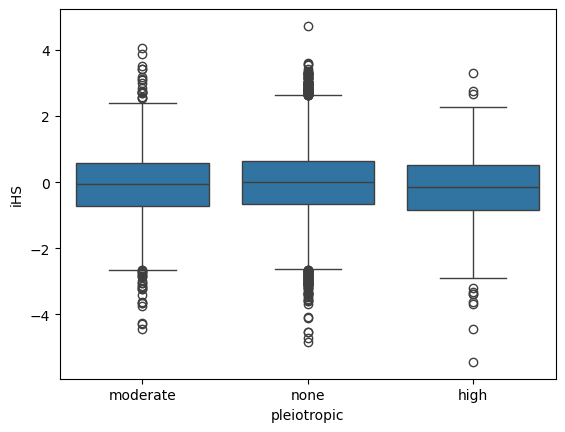

In [34]:
sns.boxplot(data=vars_pleio, x="pleiotropic", y="iHS")

In [35]:
spearmanr(vars_pleio['pdeg'], vars_pleio['iHS'], nan_policy='omit')

SpearmanrResult(correlation=-0.02853505559707707, pvalue=0.00025856770636060246)

### Case 2. Looking at the whole locus (100,000)

In [37]:
leads_positions = {}
for idx, pheno in enumerate([x for x in formatted]):
    in_file = f'{data_dir}/{pheno}'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 
                         'pval', 'chr', 'start', 'end', 'gene_name']
    for idx, row in gene_data.iterrows():
        leads_positions[row['rsid']] = (row['var_chr'], row['var_pos'])

In [38]:
hipleio_bed = open('/mnt/data/phenome_proj/evolution/iHS/fg_high_pleio.bed', 'w')
mpleio_bed = open('/mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio.bed', 'w')
other_bed = open('/mnt/data/phenome_proj/evolution/iHS/fg_other.bed', 'w')
for idx, row in vars_pleio.iterrows():
    var_chr, var_pos = leads_positions[row['rsid']]
    var_pos = int(var_pos)
    out_string = f'{var_chr}\t{var_pos - 50000}\t{var_pos + 50000}\n'
    if row['pleiotropic'] == 'high':
        hipleio_bed.write(out_string)
    elif row['pleiotropic'] == 'moderate':
        mpleio_bed.write(out_string)
    else:
        other_bed.write(out_string)
hipleio_bed.close()
mpleio_bed.close()
other_bed.close()

Preprocessing the loci BEDs before intersecting with the iHS bed

In [39]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged.bed

In [40]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged.bed

In [41]:
!sort -k1,1 -k2,2n /mnt/data/phenome_proj/evolution/iHS/fg_other.bed | \
    bedtools merge -i - > /mnt/data/phenome_proj/evolution/iHS/fg_other_merged.bed

Intersecting with the iHS bed constructed earlier

In [42]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_iHS.bed

In [43]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_iHS.bed

In [44]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_other_merged.bed \
        -b /mnt/data/phenome_proj/evolution/iHS/all_iHS.bed > \
        /mnt/data/phenome_proj/evolution/iHS/fg_other_iHS.bed

Reading the results and plotting

In [46]:
locus_ihs_dict = defaultdict(lambda: defaultdict(lambda: 0))
file_names = ['/mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_iHS.bed',
              '/mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_iHS.bed',
              '/mnt/data/phenome_proj/evolution/iHS/fg_other_iHS.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[1]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pihs_handle:
        for line in pihs_handle:
            content = line.strip().split('\t')
            if content[6] == 'NA':
                continue
            ihs_value = float(content[6])
            locus_coords = f'{content[0]}:{content[1]}-{content[2]}'
            if ihs_value > locus_ihs_dict[pleio_cat][locus_coords]:
                locus_ihs_dict[pleio_cat][locus_coords] = ihs_value

type_list = []
value_list = []
for pleio_cat in locus_ihs_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_ihs_dict[pleio_cat]])
    value_list.extend(list(locus_ihs_dict[pleio_cat].values()))
    
loci_maxihs = pd.DataFrame({'type': type_list,
            'iHS': value_list})
loci_maxihs.head()

high
moderate
other


,type,iHS
0,high,1.632
1,high,3.939
2,high,2.329
3,high,2.611
4,high,2.082


<AxesSubplot:xlabel='type', ylabel='iHS'>

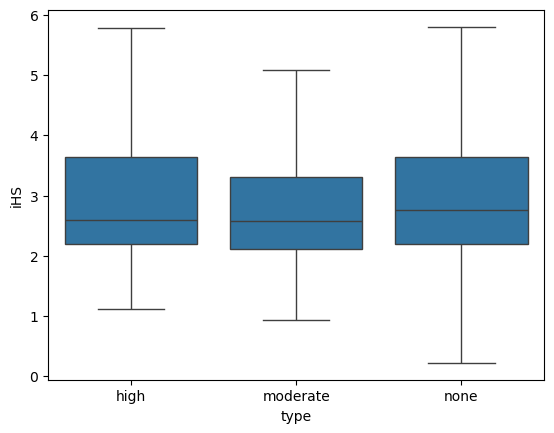

In [47]:
sns.boxplot(data=loci_maxihs, x="type", y="iHS", showfliers=False)

In [73]:
loci_maxihs.to_csv('/mnt/data/phenome_proj/evolution/fg_locus_maxihs.tsv', 
                   sep='\t', index=False)

## Comparing DRC150 values

In [49]:
asmc_data = pd.read_csv('/mnt/data/phenome_proj/evolution/DRC_150.180813.bed',
                       sep='\t', header=None)

In [50]:
asmc_scores = defaultdict(lambda: None)
for idx, row in asmc_data.iterrows():
    var_name = (row[0], row[2])
    asmc_scores[var_name] = row[3]

In [51]:
vars_pleio['DRC150'] = [asmc_scores[leads_positions[x]] for x in vars_pleio['rsid']]

In [52]:
Counter([np.isnan(x) for x in vars_pleio['DRC150']])

Counter({True: 22566, False: 34})

There's too few variants to analyze, so probably I have to go for the locus-wide analysis. Hence, I have to do the intersection/

In [53]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/fg_high_pleio_DRC150.bed

In [54]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/fg_moderate_pleio_DRC150.bed

In [55]:
!bedtools intersect -wo -a /mnt/data/phenome_proj/evolution/iHS/fg_other_merged.bed \
    -b /mnt/data/phenome_proj/evolution/DRC_150.180813.bed > \
    /mnt/data/phenome_proj/evolution/fg_other_DRC150.bed

In [56]:
locus_drc_dict = defaultdict(lambda: defaultdict(lambda: 0))
file_names = ['/mnt/data/phenome_proj/evolution/fg_high_pleio_DRC150.bed',
              '/mnt/data/phenome_proj/evolution/fg_moderate_pleio_DRC150.bed',
              '/mnt/data/phenome_proj/evolution/fg_other_DRC150.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[1]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pdrc_handle:
        for line in pdrc_handle:
            content = line.strip().split('\t')
            if content[6] == 'NA':
                continue
            drc_value = float(content[6])
            locus_coords = f'{content[0]}:{content[1]}-{content[2]}'
            if drc_value > locus_drc_dict[pleio_cat][locus_coords]:
                locus_drc_dict[pleio_cat][locus_coords] = drc_value

type_list = []
value_list = []
for pleio_cat in locus_drc_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_drc_dict[pleio_cat]])
    value_list.extend(list(locus_drc_dict[pleio_cat].values()))
    
loci_maxdrc = pd.DataFrame({'type': type_list,
            'DRC150': value_list})
loci_maxdrc.head()

high
moderate
other


,type,DRC150
0,high,0.001861
1,high,0.001920
2,high,0.001328
3,high,0.001279
4,high,0.001877


<AxesSubplot:xlabel='type', ylabel='DRC150'>

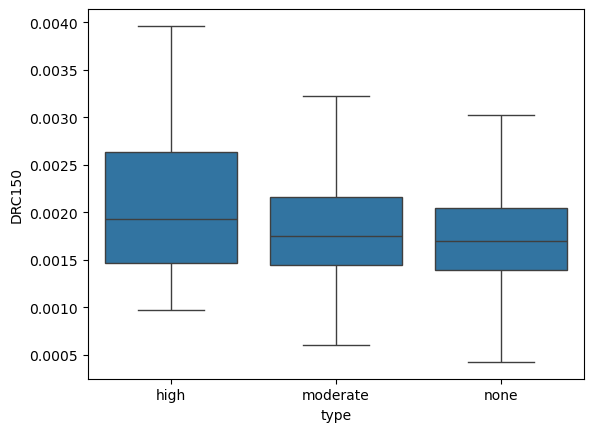

In [57]:
sns.boxplot(data=loci_maxdrc, x="type", y="DRC150", showfliers=False)

In [72]:
loci_maxdrc.to_csv('/mnt/data/phenome_proj/evolution/fg_locus_maxdrc.tsv', 
                   sep='\t', index=False)

## Comparison of the phastCons scores

In [62]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged_withChr.bed

In [63]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged_withChr.bed

In [64]:
!perl -pe 's|^|chr|' /mnt/data/phenome_proj/evolution/iHS/fg_other_merged.bed \
    > /mnt/data/phenome_proj/evolution/iHS/fg_other_merged_withChr.bed

In [65]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/fg_high_pleio_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/fg_high_pleio_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [66]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/fg_moderate_pleio_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/fg_moderate_pleio_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [67]:
!/mnt/data/phenome_proj/evolution/phastCons/isec_phastCons.sh \
    /mnt/data/phenome_proj/evolution/iHS/fg_other_merged_withChr.bed \
    /mnt/data/phenome_proj/evolution/phastCons/fg_other_phastCons

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, done! Merging...


In [68]:
locus_phc_dict = defaultdict(lambda: defaultdict(lambda: []))
file_names = ['/mnt/data/phenome_proj/evolution/phastCons/fg_high_pleio_phastCons.bed',
              '/mnt/data/phenome_proj/evolution/phastCons/fg_moderate_pleio_phastCons.bed',
              '/mnt/data/phenome_proj/evolution/phastCons/fg_other_phastCons.bed']
for curr_file in file_names:
    pleio_cat = curr_file.split('/')[-1].split('_')[1]
    print(pleio_cat)
    # Processing the file
    with open(curr_file, 'r') as pphc_handle:
        for line in pphc_handle:
            content = line.strip().split('\t')
#            locus_length = int(content[6]) - int(content[5])
            phc_value = float(content[3]) # /locus_length
            locus_coords = f'{content[4]}:{content[5]}-{content[6]}'
            window_len = int(content[2]) - int(content[1])
            for _ in range(window_len):
                locus_phc_dict[pleio_cat][locus_coords].append(phc_value)

type_list = []
value_list = []
for pleio_cat in locus_phc_dict:
    pleio_cat_names = {'other': "none", 'high': "high", 'moderate': "moderate"}
    type_list.extend([pleio_cat_names[pleio_cat] for _ in locus_phc_dict[pleio_cat]])
    score_lists = list(locus_phc_dict[pleio_cat].values())
    averaged_scores = [np.mean(x) for x in score_lists]
    value_list.extend(averaged_scores)
    
loci_meanphc = pd.DataFrame({'type': type_list,
            'phastCons': value_list})
loci_meanphc.head()

high
moderate
other


,type,phastCons
0,high,0.095264
1,high,0.206048
2,high,0.125541
3,high,0.134567
4,high,0.161555


<AxesSubplot:xlabel='type', ylabel='phastCons'>

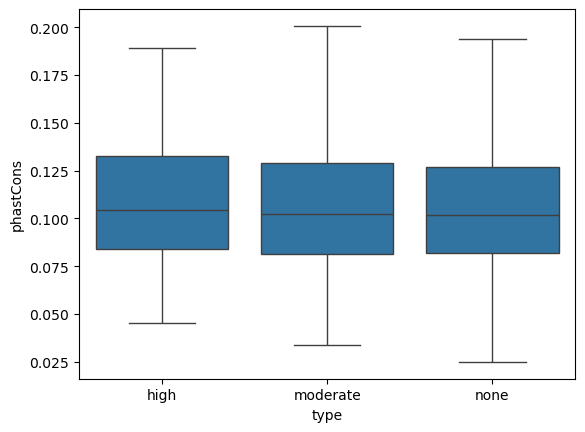

In [69]:
sns.boxplot(data=loci_meanphc, x="type", y="phastCons", showfliers=False)

In [70]:
loci_meanphc.groupby('type').mean()

,phastCons
type,
high,0.111552
moderate,0.108849
none,0.106772


In [71]:
loci_meanphc.to_csv('/mnt/data/phenome_proj/evolution/fg_locus_meanphc.tsv',
                   sep='\t', index=False)

## Checking for interval size confounding

It may be hypothesized that the observed enrichment with high scores (both iHS and DRC150) may arise from the larger interval sizes. To test for this, the simplest option is to just compute the average size of an interval in a group:

In [186]:
!for i in /mnt/data/phenome_proj/evolution/iHS/fg_*merged.bed ; \
    do echo $i ; awk '{ sum+=$3-$2 } END { print sum/NR }' $i ; done

/mnt/data/phenome_proj/evolution/iHS/high_pleio_merged.bed
118747
/mnt/data/phenome_proj/evolution/iHS/moderate_pleio_merged.bed
131373
/mnt/data/phenome_proj/evolution/iHS/other_merged.bed
173615
